In [2]:
# Importer les bibliothèques necessaires
!pip install gdown
import gdown
import pandas as pd
import re
import gc
import os
import sys
import pandas as pd
import numpy as np
import tqdm
import seaborn as sns

import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.model_selection import train_test_split, StratifiedKFold, KFold
from sklearn.metrics import roc_auc_score
from sklearn.linear_model import LogisticRegression
from scipy.stats import chi2_contingency
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import precision_score, recall_score, roc_curve, auc, classification_report, confusion_matrix, roc_auc_score
from sklearn.svm import SVC


[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [3]:
import os
print("Dossier actuel :", os.getcwd())
print("Contenu du dossier actuel :", os.listdir('..'))

Dossier actuel : /home/onyxia/work/PROJET_STATAPP_MILLIMAN/notebook
Contenu du dossier actuel : ['.git', 'README.md', '.gitignore', 'utils', 'Analyses_descriptives', 'Annexe', 'Génération de données synthétiques', 'notebook']


In [4]:
!pip install lightgbm
import lightgbm as lgb


[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [5]:
import sys
import os 
import importlib
sys.path.append("..")

# On récupère le dossier où se trouve ton notebook
dossier_notebook = os.getcwd()

# On remonte d'un cran pour atteindre le dossier racine du projet
dossier_racine = os.path.abspath(os.path.join(dossier_notebook, '..'))

if dossier_racine not in sys.path:
    sys.path.append(dossier_racine)

from utils import fonctions_utiles as fu 
importlib.reload(fu) 


<module 'utils.fonctions_utiles' from '/home/onyxia/work/PROJET_STATAPP_MILLIMAN/notebook/../utils/fonctions_utiles.py'>

In [6]:
np.random.seed(123)

In [7]:
# Charger les données
df = pd.read_csv('Fraud Detection Dataset.csv')  # changer le nom du fichier si nécessaire
print('Forme du dataset chargé :', df.shape)
print(df['Fraudulent'].value_counts())


Forme du dataset chargé : (51000, 12)
Fraudulent
0    48490
1     2510
Name: count, dtype: int64


# **Sommaire**

### Traitement des valeurs manquantes Na
1. 1ère méthode : moyenne
2. 2ème méthode : Interpolation Bayesienne

### Implémentation des modèles de classification
1. *RandomForest*
2. *Régression Logistique*
3. *SVM*
4. *LightGBM*

### Algorithme de génération de données synthétiques : SMOTE

0. Implémentation SMOTE

### Résultats **sans SMOTE**
1. Mesures d'évaluation des modèles
2. Comparaison des courbes ROC et AUC 


### Résultats **avec SMOTE**
1. Mesures d'évaluation des modèles
2. Comparaison des courbes ROC et AUC 



## **Traitement des valeurs manquantes Na**


### **1ère méthode : moyenne**

Implémentation fonction *missing_mean*

Preprocessing : 
Séparation des variables explicatives X de la variable expliquée y 

In [8]:
def separation(data):
    y=data['Fraudulent']
    X=data.drop(columns=['Fraudulent'])
    # Encodage des colonnes catégorielles
    for col in X.select_dtypes(include=['object','category']).columns:
        X[col] = LabelEncoder().fit_transform(X[col].astype(str))
    return X, y

In [9]:
X,y = separation(df)

In [10]:
# Split du dataset

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.35, 
random_state=42, stratify=y)

Remplissage des valeurs manquantes sur la base train uniquement

In [11]:
# ── Imputation sans fuite de données : Fit sur le train, Transform sur train ET test ──

train_full = pd.concat([X_train, y_train], axis=1)

# 1. FIT — extraire les statistiques d'imputation depuis le train uniquement
imputation_stats = {}
numeric_cols     = train_full.select_dtypes(include=['int64', 'float64']).columns.drop('Fraudulent')
categorical_cols = train_full.select_dtypes(include=['object', 'category']).columns

for col in numeric_cols:
    imputation_stats[col] = {
        fraud_val: train_full.loc[train_full['Fraudulent'] == fraud_val, col].mean()
        for fraud_val in [0, 1]
    }

for col in categorical_cols:
    imputation_stats[col] = {}
    for fraud_val in [0, 1]:
        mode_s = train_full.loc[train_full['Fraudulent'] == fraud_val, col].mode()
        if not mode_s.empty:
            imputation_stats[col][fraud_val] = mode_s.iloc[0]

# 2. TRANSFORM TRAIN — comportement identique à fu.missing_mean mais avec stats train uniquement
X_train, y_train = separation(fu.missing_mean(train_full))

# 3. TRANSFORM TEST — appliquer les stats calculées sur le train (pas de fuite)
test_full = pd.concat([X_test, y_test], axis=1).copy()

for col in numeric_cols:
    for fraud_val in [0, 1]:
        mask = (test_full['Fraudulent'] == fraud_val) & (test_full[col].isna())
        test_full.loc[mask, col] = imputation_stats[col][fraud_val]

for col in categorical_cols:
    for fraud_val in [0, 1]:
        mask = (test_full['Fraudulent'] == fraud_val) & (test_full[col].isna())
        if fraud_val in imputation_stats.get(col, {}):
            test_full.loc[mask, col] = imputation_stats[col][fraud_val]

X_test, y_test = separation(test_full)

# Vérification
print('NaN restants dans X_train :', X_train.isna().sum().sum())
print('NaN restants dans X_test  :', X_test.isna().sum().sum())


Pourcentage de valeurs manquantes après traitement :
Transaction_ID                      0.0
User_ID                             0.0
Transaction_Amount                  0.0
Transaction_Type                    0.0
Time_of_Transaction                 0.0
Device_Used                         0.0
Location                            0.0
Previous_Fraudulent_Transactions    0.0
Account_Age                         0.0
Number_of_Transactions_Last_24H     0.0
Payment_Method                      0.0
Fraudulent                          0.0
dtype: float64
NaN restants dans X_train : 0
NaN restants dans X_test  : 0


/home/onyxia/work/PROJET_STATAPP_MILLIMAN/notebook/../utils/fonctions_utiles.py:54: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '25039.976870359795' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_c.loc[(df_c['Fraudulent'] == fraud_value) & (df_c[col].isna()),col] = mean_value
/home/onyxia/work/PROJET_STATAPP_MILLIMAN/notebook/../utils/fonctions_utiles.py:54: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '2996.783932990672' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_c.loc[(df_c['Fraudulent'] == fraud_value) & (df_c[col].isna()),col] = mean_value
/home/onyxia/work/PROJET_STATAPP_MILLIMAN/notebook/../utils/fonctions_utiles.py:54: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future ve

### **Implémentation des modèles de classification**


### 1. *RandomForest*

### 2. *Régression Logistique*

Implémentation fonction *logistic*

### 3. *SVM*

### 4. *LightGBM*

### **Algorithme de génération de données synthétiques : SMOTE**

0. Implémentation fonction *smote*

In [12]:
!pip install imblearn 


[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


### **Métriques d'évaluation des modèles et courbes ROC (et AUC)**

1. Implémentation fonction résultat métriques

2. Implémentation fonction de tracé des courbes ROC

### **Résultats sans SMOTE**

1. **Mesures** d'évaluation des modèles *(precision, accuracy, recall, specificity, f1-score)*

RandomForest

threshold avec Youden: 0.08
recall (sensitivity) avec Youden : 0.3906605922551253
precision avec Youden:0.08247422680412371
specificity avec Youden: 0.7563634221069998
f1-score avec Youden : 0.15932914046121593
Indice de Youden: 0.14702401436212506
accuracy:0.9550700280112044
recall (sensitivity) au seuil de 50% : 0.08656036446469248
precision au seuil de 50%:1.0
f1-score au seuil de 50% : 0.13619555776150885
accuracy:0.9550700280112044
AUC: 0.6000389157647836
              precision    recall  f1-score   support

           0       0.95      1.00      0.98     16972
           1       1.00      0.09      0.16       878

    accuracy                           0.96     17850
   macro avg       0.98      0.54      0.57     17850
weighted avg       0.96      0.96      0.94     17850



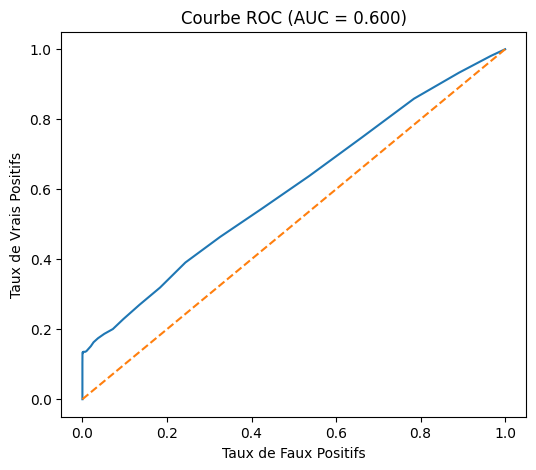

In [13]:
y_pred, y_pred_proba = fu.random_forest(X_train, y_train, X_test, y_test)
fu.metrics(y_pred, y_pred_proba,X_test, y_test,False)
fu.roc(y_pred, y_pred_proba,X_test, y_test,False)

LightGBM

[LightGBM] [Info] Number of positive: 1632, number of negative: 31518
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001499 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 956
[LightGBM] [Info] Number of data points in the train set: 33150, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.049231 -> initscore=-2.960753
[LightGBM] [Info] Start training from score -2.960753
threshold avec Youden: 0.05657835947852305
recall (sensitivity) avec Youden : 0.3348519362186788
precision avec Youden:0.08632881555686506
specificity avec Youden: 0.817287296724016
f1-score avec Youden : 0.13093980992608237
Indice de Youden: 0.15213923294269485
accuracy:0.9538935574229692
recall (sensitivity) au seuil de 50% : 0.07061503416856492
precision au seuil de 50%:0.8985507246376812
f1-score au seuil de 50% : 0.13726824371160634
accuracy:0.9538935574229692
AUC: 0.6102687154026167
              

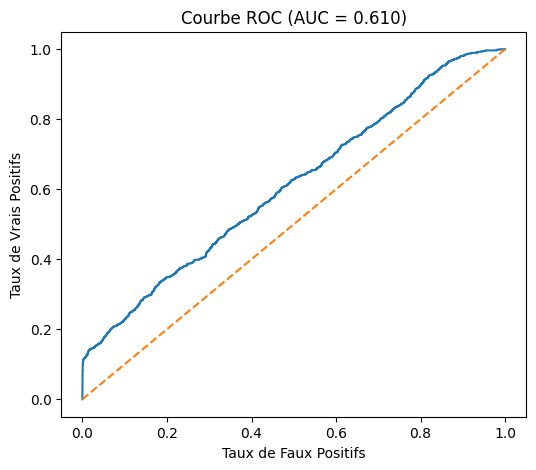

In [14]:
y_pred, y_pred_proba = fu.light_gbm(X_train, y_train, X_test, y_test)
fu.metrics(y_pred, y_pred_proba,X_test, y_test,False)
fu.roc(y_pred, y_pred_proba,X_test, y_test,False)

### **Résultats avec SMOTE**

In [15]:
## Application SMOTE à la train
X_train_s, y_train_s=fu.smote(X_train,y_train,0.2)


Après SMOTE, comptes : [31518  7879]


1. **Mesures** d'évaluation des modèles *(precision, accuracy, recall, specificity, f1-score)*

RandomForest

threshold avec Youden: 0.08
recall (sensitivity) avec Youden : 0.4293849658314351
precision avec Youden:0.060356928012833364
specificity avec Youden: 0.6531934951685128
f1-score avec Youden : 0.05966850828729282
Indice de Youden: 0.08257846099994792
accuracy:0.9523249299719888
recall (sensitivity) au seuil de 50% : 0.030751708428246014
precision au seuil de 50%:1.0
f1-score au seuil de 50% : 0.10583680015221203
accuracy:0.9523249299719888
AUC: 0.5533203019095635
              precision    recall  f1-score   support

           0       0.95      1.00      0.98     16972
           1       1.00      0.03      0.06       878

    accuracy                           0.95     17850
   macro avg       0.98      0.52      0.52     17850
weighted avg       0.95      0.95      0.93     17850



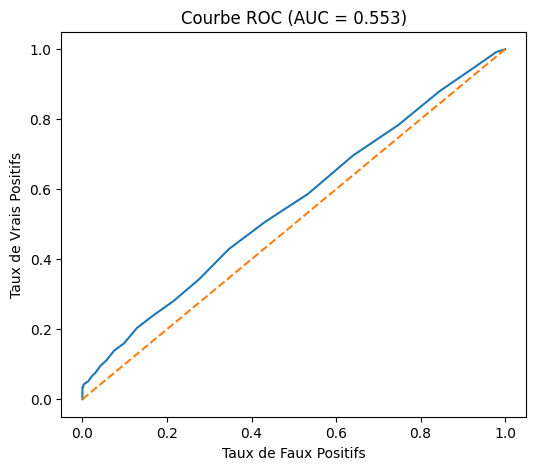

In [16]:
y_pred, y_pred_proba = fu.random_forest(X_train_s, y_train_s, X_test, y_test)
fu.metrics(y_pred, y_pred_proba,X_test, y_test,False)
fu.roc(y_pred, y_pred_proba,X_test, y_test,False)

LightGBM

[LightGBM] [Info] Number of positive: 7879, number of negative: 31518
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000314 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2804
[LightGBM] [Info] Number of data points in the train set: 39397, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.199990 -> initscore=-1.386358
[LightGBM] [Info] Start training from score -1.386358
threshold avec Youden: 0.07378108265876869
recall (sensitivity) avec Youden : 0.2460136674259681
precision avec Youden:0.09967547519703292
specificity avec Youden: 0.8855762432241339
f1-score avec Youden : 0.09719222462203024
Indice de Youden: 0.13158991065010198
accuracy:0.9531652661064426
recall (sensitivity) au seuil de 50% : 0.05125284738041002
precision au seuil de 50%:0.9375
f1-score au seuil de 50% : 0.1418704042573341
accuracy:0.95

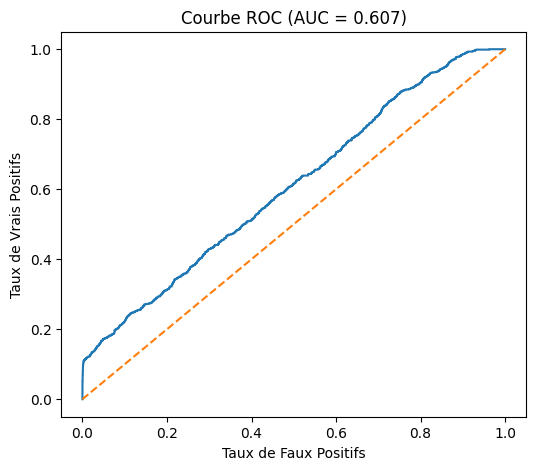

In [17]:
y_pred, y_pred_proba = fu.light_gbm(X_train_s, y_train_s, X_test, y_test)
fu.metrics(y_pred, y_pred_proba,X_test, y_test,False)
fu.roc(y_pred, y_pred_proba,X_test, y_test,False)

### **Synthèse des résultats**

Création des dataset avec missing_mean et missing_interpolation

Résultats **Sans SMOTE**

In [18]:
no_smote_col = pd.MultiIndex.from_tuples([('Sans SMOTE','Moyenne', 'recall'),('Sans SMOTE','Moyenne', 'specificity'),
                                       ('Sans SMOTE','Moyenne', 'precision'),('Sans SMOTE','Moyenne', 'f1-score'),
                                       ('Sans SMOTE','Moyenne', 'Indice de Youden'),('Sans SMOTE','Moyenne', 'seuil optimal')])



liste=[fu.random_forest,fu.light_gbm]
M=[]
for modele in liste:
    y_pred, y_pred_proba = modele(X_train, y_train, X_test, y_test)
    L=fu.metrics(y_pred, y_pred_proba,X_test, y_test,True)
    M.append(L)
df = pd.DataFrame(M,index=['RandomForest','LightGBM'],columns=no_smote_col)

[LightGBM] [Info] Number of positive: 1632, number of negative: 31518
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000446 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 956
[LightGBM] [Info] Number of data points in the train set: 33150, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.049231 -> initscore=-2.960753
[LightGBM] [Info] Start training from score -2.960753


In [19]:
df.stack(future_stack=True)

Sans SMOTE
                                 Moyenne
RandomForest recall             0.390661
             specificity        0.756363
             precision          0.082474
             f1-score           0.136196
             Indice de Youden   0.147024
             seuil optimal      0.080000
LightGBM     recall             0.334852
             specificity        0.817287
             precision          0.086329
             f1-score           0.137268
             Indice de Youden   0.152139
             seuil optimal      0.056578

Résultats **Avec SMOTE**


In [20]:
smote_col = pd.MultiIndex.from_tuples([('SMOTE','Moyenne', 'recall'),('SMOTE','Moyenne', 'specificity'),
                                       ('SMOTE','Moyenne', 'precision'),('SMOTE','Moyenne', 'f1-score'),
                                       ('SMOTE','Moyenne', 'Indice de Youden'),('SMOTE','Moyenne', 'seuil optimal')])



liste=[fu.random_forest,fu.light_gbm]
M=[]
for modele in liste:
    y_pred, y_pred_proba = modele(X_train_s, y_train_s, X_test, y_test)
    L=fu.metrics(y_pred, y_pred_proba,X_test, y_test,True) 
    M.append(L)
df = pd.DataFrame(M,index=['RandomForest','LightGBM'],columns=smote_col)

[LightGBM] [Info] Number of positive: 7879, number of negative: 31518
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000295 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2804
[LightGBM] [Info] Number of data points in the train set: 39397, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.199990 -> initscore=-1.386358
[LightGBM] [Info] Start training from score -1.386358


In [21]:
df.stack(future_stack=True)

SMOTE
                                Moyenne
RandomForest recall            0.429385
             specificity       0.653193
             precision         0.060357
             f1-score          0.105837
             Indice de Youden  0.082578
             seuil optimal     0.080000
LightGBM     recall            0.246014
             specificity       0.885576
             precision         0.099675
             f1-score          0.141870
             Indice de Youden  0.131590
             seuil optimal     0.073781

AUC **sans SMOTE**

In [22]:
no_smote_col = pd.MultiIndex.from_tuples([('Sans SMOTE','Moyenne', 'AUC')])

liste=[fu.random_forest,fu.light_gbm]
M=[]
for modele in liste:
    y_pred, y_pred_proba = modele(X_train, y_train, X_test, y_test)
    L=fu.roc(y_pred, y_pred_proba,X_test, y_test,True) 
    M.append(L)
df = pd.DataFrame(M,index=['RandomForest','LightGBM'],columns=no_smote_col)

[LightGBM] [Info] Number of positive: 1632, number of negative: 31518
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000424 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 956
[LightGBM] [Info] Number of data points in the train set: 33150, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.049231 -> initscore=-2.960753
[LightGBM] [Info] Start training from score -2.960753


In [23]:
df.stack(future_stack=True)

,,Sans SMOTE
,,Moyenne
RandomForest,AUC,0.600039
LightGBM,AUC,0.610269


AUC **avec SMOTE**

In [24]:
smote_col = pd.MultiIndex.from_tuples([('SMOTE','Moyenne', 'AUC')])

liste=[fu.random_forest,fu.light_gbm]
M=[]
for modele in liste:
    y_pred, y_pred_proba = modele(X_train_s, y_train_s, X_test, y_test)
    L=fu.roc(y_pred, y_pred_proba,X_test, y_test,True) 
    M.append(L)
df = pd.DataFrame(M,index=['RandomForest','LightGBM'],columns=smote_col)

[LightGBM] [Info] Number of positive: 7879, number of negative: 31518
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000368 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2804
[LightGBM] [Info] Number of data points in the train set: 39397, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.199990 -> initscore=-1.386358
[LightGBM] [Info] Start training from score -1.386358


In [25]:
df.stack(future_stack=True)

,,SMOTE
,,Moyenne
RandomForest,AUC,0.553320
LightGBM,AUC,0.606567


### **Conclusion sur le choix du modèle :**

Au vu de l'ensemble des performances, le modèle choisi est donc le lightGBM. 

Modifions les paramètres d'entrée du classificateur afin d'améliorer les performances du modèle. 

In [26]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
import lightgbm as lgb

# ─────────────────────────────────────────────
# Grilles d'hyperparamètres
# ─────────────────────────────────────────────

param_dist_rf = {
    'n_estimators':      [100, 200, 300, 500],
    'max_depth':         [None, 10, 20, 30, 50],
    'min_samples_split': randint(2, 20),
    'min_samples_leaf':  randint(1, 10),
    'max_features':      ['sqrt', 'log2'],
    'bootstrap':         [True],
}

param_dist_lgbm = {
    'n_estimators': [50, 100, 500, 2000],
    'learning_rate': [0.01, 0.05, 0.1],
    'num_leaves': [10, 20, 30, 40, 50],
    'max_depth': [-1, 3, 6, 9, 12],
    'min_child_samples': [10, 20, 30],
}

# Pour les pipelines avec SMOTE, les hyperparamètres
# doivent être préfixés du nom du step ('clf__')
param_dist_rf_smote = {f'clf__{k}': v for k, v in param_dist_rf.items()}
param_dist_lgbm_smote = {f'clf__{k}': v for k, v in param_dist_lgbm.items()}


# ─────────────────────────────────────────────
# Fonction générique de fine-tuning
# ─────────────────────────────────────────────

def fine_tune(estimator, param_dist, X_tr, y_tr, label):
    search = RandomizedSearchCV(
        estimator=estimator,
        param_distributions=param_dist,
        n_iter=50,
        cv=5,
        scoring='roc_auc',   # cohérent avec l'évaluation finale
        n_jobs=-1,
        verbose=1,
        random_state=42,
        return_train_score=True,
    )
    search.fit(X_tr, y_tr)
    print(f"\n[{label}] Meilleurs paramètres : {search.best_params_}")
    print(f"[{label}] Meilleur AUC CV       : {search.best_score_:.4f}")
    return search


# ─────────────────────────────────────────────
# 1. Random Forest — sans SMOTE
# ─────────────────────────────────────────────

rs_rf = fine_tune(
    estimator  = RandomForestClassifier(random_state=42),
    param_dist = param_dist_rf,
    X_tr       = X_train,
    y_tr       = y_train,
    label      = "RF sans SMOTE",
)

# ─────────────────────────────────────────────
# 2. Random Forest — avec SMOTE dans le pipeline
# ─────────────────────────────────────────────

pipeline_rf = Pipeline([
    ('smote', SMOTE(sampling_strategy=0.25, random_state=42)),
    ('clf',   RandomForestClassifier(random_state=42)),
])

rs_rf_smote = fine_tune(
    estimator  = pipeline_rf,
    param_dist = param_dist_rf_smote,
    X_tr       = X_train,   # ← données originales, SMOTE appliqué à l'intérieur du CV
    y_tr       = y_train,
    label      = "RF avec SMOTE",
)

# ─────────────────────────────────────────────
# 3. LightGBM — sans SMOTE
# ─────────────────────────────────────────────

rs_lgbm = fine_tune(
    estimator  = lgb.LGBMClassifier(random_state=42, verbose=-1),
    param_dist = param_dist_lgbm,
    X_tr       = X_train,
    y_tr       = y_train,
    label      = "LGBM sans SMOTE",
)

# ─────────────────────────────────────────────
# 4. LightGBM — avec SMOTE dans le pipeline
# ─────────────────────────────────────────────

pipeline_lgbm = Pipeline([
    ('smote', SMOTE(sampling_strategy=0.25, random_state=42)),
    ('clf',   lgb.LGBMClassifier(random_state=42, verbose=-1)),
])

rs_lgbm_smote = fine_tune(
    estimator  = pipeline_lgbm,
    param_dist = param_dist_lgbm_smote,
    X_tr       = X_train,
    y_tr       = y_train,
    label      = "LGBM avec SMOTE",
)

Fitting 5 folds for each of 50 candidates, totalling 250 fits



[RF sans SMOTE] Meilleurs paramètres : {'bootstrap': True, 'max_depth': 10, 'max_features': 'log2', 'min_samples_leaf': 3, 'min_samples_split': 8, 'n_estimators': 100}
[RF sans SMOTE] Meilleur AUC CV       : 0.6019
Fitting 5 folds for each of 50 candidates, totalling 250 fits

[RF avec SMOTE] Meilleurs paramètres : {'clf__bootstrap': True, 'clf__max_depth': 50, 'clf__max_features': 'log2', 'clf__min_samples_leaf': 2, 'clf__min_samples_split': 7, 'clf__n_estimators': 200}
[RF avec SMOTE] Meilleur AUC CV       : 0.5553
Fitting 5 folds for each of 50 candidates, totalling 250 fits

[LGBM sans SMOTE] Meilleurs paramètres : {'num_leaves': 50, 'n_estimators': 50, 'min_child_samples': 30, 'max_depth': -1, 'learning_rate': 0.05}
[LGBM sans SMOTE] Meilleur AUC CV       : 0.6125
Fitting 5 folds for each of 50 candidates, totalling 250 fits

[LGBM avec SMOTE] Meilleurs paramètres : {'clf__num_leaves': 50, 'clf__n_estimators': 2000, 'clf__min_child_samples': 10, 'clf__max_depth': 6, 'clf__learnin


  RF sans SMOTE
threshold avec Youden: 0.06081799341078464
recall (sensitivity) avec Youden : 0.2744874715261959
precision avec Youden:0.10122311261071278
specificity avec Youden: 0.8744402545368843
f1-score avec Youden : 0.08922742110990206
Indice de Youden: 0.1489277260630802
accuracy:0.953109243697479
recall (sensitivity) au seuil de 50% : 0.04669703872437358
precision au seuil de 50%:1.0
f1-score au seuil de 50% : 0.1479036120547581
accuracy:0.953109243697479
AUC: 0.597034067098053
              precision    recall  f1-score   support

           0       0.95      1.00      0.98     16972
           1       1.00      0.05      0.09       878

    accuracy                           0.95     17850
   macro avg       0.98      0.52      0.53     17850
weighted avg       0.96      0.95      0.93     17850



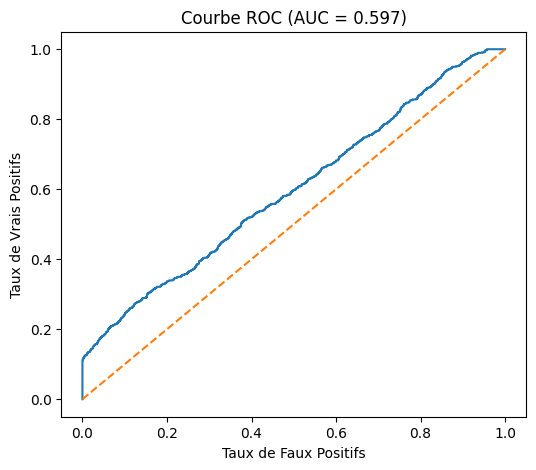


  RF avec SMOTE
threshold avec Youden: 0.10023538961038961
recall (sensitivity) avec Youden : 0.23348519362186787
precision avec Youden:0.0703448275862069
specificity avec Youden: 0.8411501296252651
f1-score avec Youden : 0.0022753128555176336
Indice de Youden: 0.07463532324713301
accuracy:0.9508683473389355
recall (sensitivity) au seuil de 50% : 0.0011389521640091116
precision au seuil de 50%:1.0
f1-score au seuil de 50% : 0.10811621329555383
accuracy:0.9508683473389355
AUC: 0.5462519803487131
              precision    recall  f1-score   support

           0       0.95      1.00      0.97     16972
           1       1.00      0.00      0.00       878

    accuracy                           0.95     17850
   macro avg       0.98      0.50      0.49     17850
weighted avg       0.95      0.95      0.93     17850



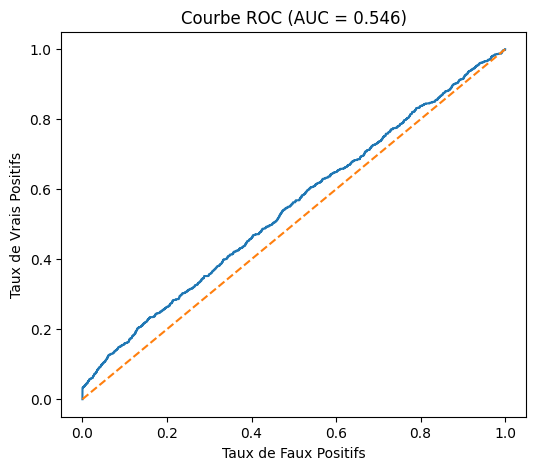


  LGBM sans SMOTE
threshold avec Youden: 0.052245853463074025
recall (sensitivity) avec Youden : 0.38724373576309795
precision avec Youden:0.07874564459930314
specificity avec Youden: 0.7663209992929532
f1-score avec Youden : 0.12366737739872068
Indice de Youden: 0.15356473505605106
accuracy:0.9539495798319327
recall (sensitivity) au seuil de 50% : 0.06605922551252848
precision au seuil de 50%:0.9666666666666667
f1-score au seuil de 50% : 0.13087747864980226
accuracy:0.9539495798319327
AUC: 0.6104091047454818
              precision    recall  f1-score   support

           0       0.95      1.00      0.98     16972
           1       0.97      0.07      0.12       878

    accuracy                           0.95     17850
   macro avg       0.96      0.53      0.55     17850
weighted avg       0.95      0.95      0.93     17850



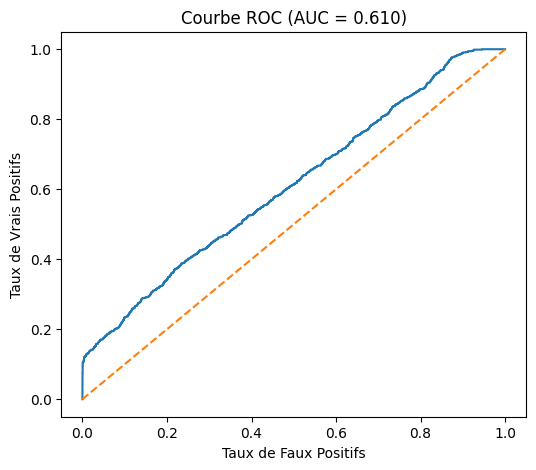


  LGBM avec SMOTE
threshold avec Youden: 0.039803616331703894
recall (sensitivity) avec Youden : 0.6264236902050114
precision avec Youden:0.060763696734919756
specificity avec Youden: 0.5
f1-score avec Youden : 0.11902231668437832
Indice de Youden: 0.12642369020501143
accuracy:0.9535574229691877
recall (sensitivity) au seuil de 50% : 0.06378132118451026
precision au seuil de 50%:0.8888888888888888
f1-score au seuil de 50% : 0.11078148366106112
accuracy:0.9535574229691877
AUC: 0.6043563242580436
              precision    recall  f1-score   support

           0       0.95      1.00      0.98     16972
           1       0.89      0.06      0.12       878

    accuracy                           0.95     17850
   macro avg       0.92      0.53      0.55     17850
weighted avg       0.95      0.95      0.93     17850



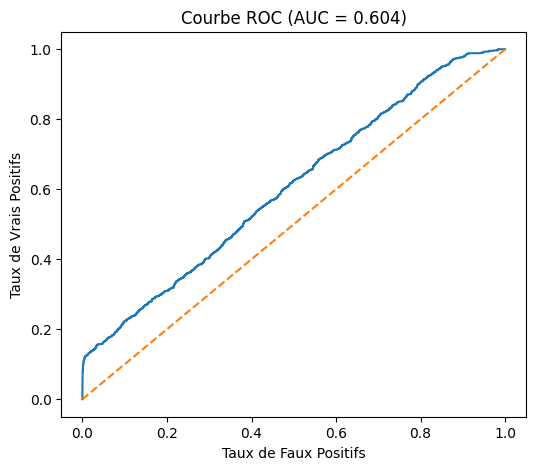

,AUC CV (validation)
RF sans SMOTE,0.6019
RF avec SMOTE,0.5553
LGBM sans SMOTE,0.6125
LGBM avec SMOTE,0.6037


In [28]:
# ─────────────────────────────────────────────
# Évaluation des 4 modèles sur X_test
# ─────────────────────────────────────────────

results_finetuning = {}

for label, search in [
    ("RF sans SMOTE",   rs_rf),
    ("RF avec SMOTE",   rs_rf_smote),
    ("LGBM sans SMOTE", rs_lgbm),
    ("LGBM avec SMOTE", rs_lgbm_smote),
]:
    best = search.best_estimator_
    y_pred       = best.predict(X_test)
    y_pred_proba = best.predict_proba(X_test)

    print(f"\n{'='*45}")
    print(f"  {label}")
    print(f"{'='*45}")
    fu.metrics(y_pred, y_pred_proba, X_test, y_test, False)
    fu.roc(y_pred, y_pred_proba, X_test, y_test, False)

    results_finetuning[label] = search.best_score_

# Tableau comparatif
import pandas as pd
pd.DataFrame.from_dict(results_finetuning, orient='index',
                       columns=['AUC CV (validation)']).round(4)